**Drug Repurposing Candidate Identification Using Differential Gene Expression and Drug–Gene Interaction Databases**

End-to-End Bioinformatics Pipeline Using Databricks and Python

**Author:** Ume Abiha

**Project Overview**

This project integrates differential gene expression results from a TCGA-BRCA breast cancer analysis with drug–gene interaction data from the Drug Gene Interaction Database (DGIdb).
The objective is to identify significantly dysregulated genes, determine which of these genes are druggable, and prioritize existing drugs that may represent computational candidates for drug repurposing.
This workflow demonstrates the integration of transcriptomic analysis, statistical testing, biological databases, and network analysis using Python in Databricks.

**1. Load Differential Gene Expression Results**

In [0]:
import pandas as pd
import numpy as np

# Load Differential Gene Expression Results
dge_df = pd.read_csv("dge_results.csv")

print("Dataset Shape:", dge_df.shape)

dge_df.head()


Dataset Shape: (20530, 7)


,Gene,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P,Significance
0,KRTAP13-4,0.015289,0.418334,-0.482306,6.218631e-73,72.206305,Not Significant
1,AADACL2,0.158196,1.423585,-1.065263,2.309154e-70,69.636547,Downregulated
2,CPA1,0.745907,4.601289,-1.681782,7.199003e-69,68.142728,Downregulated
3,LOC572558,0.613613,3.707292,-1.544603,1.631806e-68,67.787331,Downregulated
4,CA4,1.500376,8.104417,-1.864422,2.377527e-68,67.623875,Downregulated


In [0]:
dge_df.describe()

,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P
count,20530.000000,20530.000000,20530.000000,2.053000e+04,20530.000000
mean,6.420177,6.571033,-0.031638,9.811985e-02,14.263067
std,3.913483,3.914258,0.277157,2.310476e-01,15.734750
min,0.000000,0.000000,-1.891652,6.218631e-73,-0.000000
25%,2.736453,3.114874,-0.098468,4.751100e-23,1.724076
50%,7.583228,7.739818,-0.002174,1.055487e-08,7.976547
75%,9.603595,9.683428,0.065103,1.887663e-02,22.323207
max,16.466587,16.947503,2.063068,1.000000e+00,72.206305


**2. Apply False Discovery Rate (FDR) Correction**

RNA-seq experiments test over 20,000 genes simultaneously. To reduce false positive findings caused by multiple hypothesis testing, the Benjamini–Hochberg False Discovery Rate (FDR) correction is applied to all p-values. Genes with an adjusted p-value below 0.05 are considered statistically significant.

In [0]:
from statsmodels.stats.multitest import multipletests

In [0]:
# Apply Benjamini-Hochberg False Discovery Rate correction

dge_df["Adjusted_P"] = multipletests(
    dge_df["P_Value"],
    alpha=0.05,
    method="fdr_bh"
)[1]

print("FDR correction applied successfully!")

dge_df.head()

FDR correction applied successfully!


,Gene,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P,Significance,Adjusted_P
0,KRTAP13-4,0.015289,0.418334,-0.482306,6.218631e-73,72.206305,Not Significant,1.276685e-68
1,AADACL2,0.158196,1.423585,-1.065263,2.309154e-70,69.636547,Downregulated,2.370347e-66
2,CPA1,0.745907,4.601289,-1.681782,7.199003e-69,68.142728,Downregulated,4.926518e-65
3,LOC572558,0.613613,3.707292,-1.544603,1.631806e-68,67.787331,Downregulated,8.375246e-65
4,CA4,1.500376,8.104417,-1.864422,2.377527e-68,67.623875,Downregulated,9.762124e-65


**3. Filter Significant Differentially Expressed Genes**

In [0]:
# Keep genes significant after FDR correction

significant_genes = dge_df[dge_df["Adjusted_P"] < 0.05]

print("Number of significant genes after FDR correction:")
print(significant_genes.shape[0])

Number of significant genes after FDR correction:
15890


In [0]:
# Display the most significant genes
significant_genes.sort_values("Adjusted_P").head(10)

,Gene,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P,Significance,Adjusted_P
0,KRTAP13-4,0.015289,0.418334,-0.482306,6.218631e-73,72.206305,Not Significant,1.276685e-68
1,AADACL2,0.158196,1.423585,-1.065263,2.309154e-70,69.636547,Downregulated,2.370347e-66
2,CPA1,0.745907,4.601289,-1.681782,7.199003e-69,68.142728,Downregulated,4.926518e-65
3,LOC572558,0.613613,3.707292,-1.544603,1.631806e-68,67.787331,Downregulated,8.375246e-65
4,CA4,1.500376,8.104417,-1.864422,2.377527e-68,67.623875,Downregulated,9.762124e-65
5,FIGF,3.033205,9.188756,-1.336979,5.836389e-68,67.233856,Downregulated,1.997018e-64
6,SDPR,6.672736,11.370902,-0.689138,1.023778e-67,66.989794,Not Significant,2.625421e-64
7,MMP11,12.315019,6.493440,0.829354,1.123838e-67,66.949296,Not Significant,2.625421e-64
8,CD300LG,3.833923,10.300038,-1.225061,1.150940e-67,66.938947,Downregulated,2.625421e-64
9,ADAMTS5,7.636122,11.178399,-0.495869,2.332673e-67,66.632146,Not Significant,4.788978e-64


In [0]:
filtered_genes = dge_df[
    (dge_df["Adjusted_P"] < 0.05) &
    (abs(dge_df["Log2FC"]) > 1)
]

print("Number of filtered genes:")
print(filtered_genes.shape[0])

Number of filtered genes:
277


In [0]:
filtered_genes = filtered_genes.sort_values(
    "Adjusted_P"
)

filtered_genes.head(20)

,Gene,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P,Significance,Adjusted_P
1,AADACL2,0.158196,1.423585,-1.065263,2.309154e-70,69.636547,Downregulated,2.370347e-66
2,CPA1,0.745907,4.601289,-1.681782,7.199003e-69,68.142728,Downregulated,4.926518e-65
3,LOC572558,0.613613,3.707292,-1.544603,1.631806e-68,67.787331,Downregulated,8.375246e-65
4,CA4,1.500376,8.104417,-1.864422,2.377527e-68,67.623875,Downregulated,9.762124e-65
5,FIGF,3.033205,9.188756,-1.336979,5.836389e-68,67.233856,Downregulated,1.997018e-64
8,CD300LG,3.833923,10.300038,-1.225061,1.150940e-67,66.938947,Downregulated,2.625421e-64
14,SCARA5,3.975129,10.371857,-1.192662,1.551377e-66,65.809283,Downregulated,2.123318e-63
19,TSLP,2.534544,6.498763,-1.085128,4.872025e-66,65.312290,Downregulated,5.001134e-63
24,COL10A1,10.552509,3.778266,1.273647,7.498335e-66,65.125035,Upregulated,6.157633e-63
25,FXYD1,3.847741,8.795413,-1.014794,8.313078e-66,65.080238,Downregulated,6.564134e-63


In [0]:
filtered_genes.to_csv(
    "filtered_dge_genes.csv",
    index=False
)

print("Filtered genes saved successfully!")

Filtered genes saved successfully!


In [0]:
# Rank genes by adjusted p-value

top_genes = filtered_genes.sort_values(
    by="Adjusted_P"
)

top_genes.head(20)

,Gene,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P,Significance,Adjusted_P
1,AADACL2,0.158196,1.423585,-1.065263,2.309154e-70,69.636547,Downregulated,2.370347e-66
2,CPA1,0.745907,4.601289,-1.681782,7.199003e-69,68.142728,Downregulated,4.926518e-65
3,LOC572558,0.613613,3.707292,-1.544603,1.631806e-68,67.787331,Downregulated,8.375246e-65
4,CA4,1.500376,8.104417,-1.864422,2.377527e-68,67.623875,Downregulated,9.762124e-65
5,FIGF,3.033205,9.188756,-1.336979,5.836389e-68,67.233856,Downregulated,1.997018e-64
8,CD300LG,3.833923,10.300038,-1.225061,1.150940e-67,66.938947,Downregulated,2.625421e-64
14,SCARA5,3.975129,10.371857,-1.192662,1.551377e-66,65.809283,Downregulated,2.123318e-63
19,TSLP,2.534544,6.498763,-1.085128,4.872025e-66,65.312290,Downregulated,5.001134e-63
24,COL10A1,10.552509,3.778266,1.273647,7.498335e-66,65.125035,Upregulated,6.157633e-63
25,FXYD1,3.847741,8.795413,-1.014794,8.313078e-66,65.080238,Downregulated,6.564134e-63


 **4. Select the Top 100 Differentially Expressed Genes**

In [0]:
top100_genes = top_genes.head(100)
print("Top genes selected:", len(top100_genes))

Top genes selected: 100


In [0]:
gene_list = top100_genes["Gene"].tolist()
gene_list[:20]

['AADACL2',
 'CPA1',
 'LOC572558',
 'CA4',
 'FIGF',
 'CD300LG',
 'SCARA5',
 'TSLP',
 'COL10A1',
 'FXYD1',
 'MESTIT1',
 'LRRC3B',
 'LOC100133920',
 'MYOC',
 'C1QTNF9',
 'HIF3A',
 'SLC22A12',
 'TRPM3',
 'IBSP',
 'KIAA0408']

In [0]:
top100_genes.to_csv(
    "top100_dge_genes.csv",
    index=False
)
print("Top 100 genes saved.")

Top 100 genes saved.


In [0]:
%pip install requests

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


**5. Retrieve Drug–Gene Interactions from DGIdb**

In [0]:
import requests
import pandas as pd

#We'll first test the API using one gene before querying all 100.

gene = "IBSP"

In [0]:
query = """
{
  genes(names: ["IBSP"]) {
    nodes {
      name
      interactions {
        drug {
          name
        }
        interactionTypes {
          type
        }
        sources {
          sourceDbName
        }
      }
    }
  }
}
"""

In [0]:
url = "https://dgidb.org/api/graphql"

response = requests.post(
    url,
    json={"query": query}
)

print(response.status_code)

200


In [0]:
data = response.json()
data

{'data': {'genes': {'nodes': [{'name': 'IBSP',
     'interactions': [{'drug': {'name': 'CYCLOSPORINE'},
       'interactionTypes': [],
       'sources': [{'sourceDbName': 'NCI'}]},
      {'drug': {'name': 'TNF-ALPHA'},
       'interactionTypes': [],
       'sources': [{'sourceDbName': 'NCI'}]},
      {'drug': {'name': 'ZOLEDRONIC ACID ANHYDROUS'},
       'interactionTypes': [],
       'sources': [{'sourceDbName': 'NCI'}]},
      {'drug': {'name': 'DAIDZEIN'},
       'interactionTypes': [],
       'sources': [{'sourceDbName': 'NCI'}]},
      {'drug': {'name': 'INSULIN, REGULAR, HUMAN'},
       'interactionTypes': [],
       'sources': [{'sourceDbName': 'NCI'}]}]}]}}}

In [0]:
import requests
import pandas as pd

url = "https://dgidb.org/api/graphql"

In [0]:
drug_results = []

for gene in gene_list:

    query = f"""
    {{
      genes(names: ["{gene}"]) {{
        nodes {{
          name
          interactions {{
            drug {{
              name
            }}
            interactionTypes {{
              type
            }}
            sources {{
              sourceDbName
            }}
          }}
        }}
      }}
    }}
    """

    response = requests.post(
        url,
        json={"query": query}
    )

    if response.status_code != 200:
        continue

    data = response.json()

    try:

        interactions = data["data"]["genes"]["nodes"][0]["interactions"]

        for interaction in interactions:

            drug = interaction["drug"]["name"]

            if interaction["interactionTypes"]:
                interaction_type = interaction["interactionTypes"][0]["type"]
            else:
                interaction_type = "Unknown"

            source = interaction["sources"][0]["sourceDbName"]

            drug_results.append(
                {
                    "Gene": gene,
                    "Drug": drug,
                    "Interaction": interaction_type,
                    "Source": source
                }
            )

    except:
        pass

In [0]:
drug_df = pd.DataFrame(drug_results)
drug_df.head()

,Gene,Drug,Interaction,Source
0,CPA1,COMPOUND 1B [PMID: 18078750],inhibitor,GuideToPharmacology
1,CA4,TOPIRAMATE,inhibitor,TEND
2,CA4,ACETAZOLAMIDE,inhibitor,GuideToPharmacology
3,CA4,COMPOUND 5B [PMID: 31287314],inhibitor,GuideToPharmacology
4,CA4,TRICHLORMETHIAZIDE,Unknown,TEND


In [0]:
print("Total drug-gene interactions:")
print(len(drug_df))

Total drug-gene interactions:
520


In [0]:
drug_df.to_csv(
    "drug_gene_interactions.csv",
    index=False
)
print("Drug interaction table saved.")

Drug interaction table saved.


In [0]:
# Inspect the raw interaction table

print("Raw rows:", len(drug_df))
print("Missing values:")
print(drug_df.isna().sum())

print("\nDuplicate rows:")
print(drug_df.duplicated().sum())

Raw rows: 520
Missing values:
Gene           0
Drug           0
Interaction    0
Source         0
dtype: int64

Duplicate rows:
0


**6. Clean Drug–Gene Interaction Data**

In [0]:
drug_clean_df = drug_df.copy()

drug_clean_df["Gene"] = (
    drug_clean_df["Gene"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_clean_df["Drug"] = (
    drug_clean_df["Drug"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_clean_df["Interaction"] = (
    drug_clean_df["Interaction"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

drug_clean_df["Source"] = (
    drug_clean_df["Source"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

# Remove exact duplicate records
drug_clean_df = drug_clean_df.drop_duplicates().reset_index(drop=True)

print("Rows after cleaning:", len(drug_clean_df))

drug_clean_df.head()

Rows after cleaning: 520


,Gene,Drug,Interaction,Source
0,CPA1,COMPOUND 1B [PMID: 18078750],inhibitor,GuideToPharmacology
1,CA4,TOPIRAMATE,inhibitor,TEND
2,CA4,ACETAZOLAMIDE,inhibitor,GuideToPharmacology
3,CA4,COMPOUND 5B [PMID: 31287314],inhibitor,GuideToPharmacology
4,CA4,TRICHLORMETHIAZIDE,unknown,TEND


In [0]:
# Select relevant differential-expression information

gene_metadata = top100_genes[
    ["Gene", "Log2FC", "Adjusted_P", "Significance"]
].copy()

gene_metadata["Gene"] = (
    gene_metadata["Gene"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Merge expression statistics with DGIdb results
drug_clean_df = drug_clean_df.merge(
    gene_metadata,
    on="Gene",
    how="left"
)

drug_clean_df.head()

,Gene,Drug,Interaction,Source,Log2FC,Adjusted_P,Significance
0,CPA1,COMPOUND 1B [PMID: 18078750],inhibitor,GuideToPharmacology,-1.681782,4.926518e-65,Downregulated
1,CA4,TOPIRAMATE,inhibitor,TEND,-1.864422,9.762124e-65,Downregulated
2,CA4,ACETAZOLAMIDE,inhibitor,GuideToPharmacology,-1.864422,9.762124e-65,Downregulated
3,CA4,COMPOUND 5B [PMID: 31287314],inhibitor,GuideToPharmacology,-1.864422,9.762124e-65,Downregulated
4,CA4,TRICHLORMETHIAZIDE,unknown,TEND,-1.864422,9.762124e-65,Downregulated


In [0]:
import numpy as np

drug_clean_df["Expression_Direction"] = np.where(
    drug_clean_df["Log2FC"] > 0,
    "Upregulated",
    "Downregulated"
)

drug_clean_df[
    [
        "Gene",
        "Drug",
        "Interaction",
        "Source",
        "Log2FC",
        "Adjusted_P",
        "Expression_Direction"
    ]
].head(10)

,Gene,Drug,Interaction,Source,Log2FC,Adjusted_P,Expression_Direction
0,CPA1,COMPOUND 1B [PMID: 18078750],inhibitor,GuideToPharmacology,-1.681782,4.926518e-65,Downregulated
1,CA4,TOPIRAMATE,inhibitor,TEND,-1.864422,9.762124e-65,Downregulated
2,CA4,ACETAZOLAMIDE,inhibitor,GuideToPharmacology,-1.864422,9.762124e-65,Downregulated
3,CA4,COMPOUND 5B [PMID: 31287314],inhibitor,GuideToPharmacology,-1.864422,9.762124e-65,Downregulated
4,CA4,TRICHLORMETHIAZIDE,unknown,TEND,-1.864422,9.762124e-65,Downregulated
5,CA4,SULTHIAME,inhibitor,ChEMBL,-1.864422,9.762124e-65,Downregulated
6,CA4,DICHLORPHENAMIDE,inhibitor,GuideToPharmacology,-1.864422,9.762124e-65,Downregulated
7,CA4,COMPOUND 5A [PMID: 31287314],inhibitor,GuideToPharmacology,-1.864422,9.762124e-65,Downregulated
8,CA4,ETHOXZOLAMIDE,inhibitor,ChEMBL,-1.864422,9.762124e-65,Downregulated
9,CA4,ACETAZOLAMIDE SODIUM,inhibitor,ChEMBL,-1.864422,9.762124e-65,Downregulated


**7. Drug Repurposing Analysis**

This section summarizes the druggability of the top differentially expressed genes by examining known drug–gene interactions retrieved from DGIdb. We evaluate how many genes have known drug interactions, identify the most druggable genes, determine drugs targeting multiple genes, and summarize interaction types.

 How many of the top 100 genes had interactions?

In [0]:
queried_gene_count = len(set(gene_list))
genes_with_drugs = drug_clean_df["Gene"].nunique()
genes_without_drugs = queried_gene_count - genes_with_drugs

druggable_percentage = (
    genes_with_drugs / queried_gene_count
) * 100

print("Genes queried:", queried_gene_count)
print("Genes with known interactions:", genes_with_drugs)
print("Genes without known interactions:", genes_without_drugs)
print(f"Percentage with known interactions: {druggable_percentage:.1f}%")

Genes queried: 100
Genes with known interactions: 33
Genes without known interactions: 67
Percentage with known interactions: 33.0%


Which genes have the most associated drugs?

In [0]:
drugs_per_gene = (
    drug_clean_df
    .groupby("Gene")["Drug"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Number_of_Drugs")
)

drugs_per_gene.head(15)

,Gene,Number_of_Drugs
0,ADRA1A,135
1,GFAP,40
2,NPY2R,34
3,GRM4,32
4,MMP1,27
5,TRPM3,24
6,APOB,24
7,LEP,24
8,MMP13,22
9,ADCYAP1R1,21


In [0]:
genes_per_drug = (
    drug_clean_df
    .groupby("Drug")["Gene"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Number_of_Genes")
)

multi_gene_drugs = genes_per_drug[
    genes_per_drug["Number_of_Genes"] > 1
].copy()

print("Unique drugs:", drug_clean_df["Drug"].nunique())
print("Drugs targeting more than one selected gene:", len(multi_gene_drugs))

multi_gene_drugs.head(20)

Unique drugs: 460
Drugs targeting more than one selected gene: 42


,Drug,Number_of_Genes
0,"INSULIN, REGULAR, HUMAN",4
1,NITREFAZOLE,3
2,TYROSINE KINASE INHIBITOR,3
3,NIFEDIPINE,3
4,DEHYDRATED ALCOHOL,3
5,DOXYCYCLINE HYCLATE,2
6,RIVAROXABAN,2
7,CYCLOSPORINE,2
8,ESTRADIOL VALERATE,2
9,LOVASTATIN,2


In [0]:
drug_target_summary = (
    drug_clean_df
    .groupby("Drug")
    .agg(
        Number_of_Genes=("Gene", "nunique"),
        Target_Genes=("Gene", lambda x: ", ".join(sorted(set(x)))),
        Sources=("Source", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
    .sort_values(
        "Number_of_Genes",
        ascending=False
    )
)

drug_target_summary.head(20)

,Drug,Number_of_Genes,Target_Genes,Sources
189,"INSULIN, REGULAR, HUMAN",4,"ADCYAP1R1, AQP7, IBSP, TDO2",NCI
276,NITREFAZOLE,3,"ADH1A, ADH1C, ADH4",ChEMBL
416,TYROSINE KINASE INHIBITOR,3,"CCL11, GFAP, MMP1",NCI
273,NIFEDIPINE,3,"ADRA1A, GFAP, TRPM3","GuideToPharmacology, NCI, PharmGKB"
118,DEHYDRATED ALCOHOL,3,"ADH4, APOB, DPP6","NCI, PharmGKB"
132,DOXYCYCLINE HYCLATE,2,"MMP1, MMP13",ChEMBL
359,RIVAROXABAN,2,"APOB, MMP13",PharmGKB
107,CYCLOSPORINE,2,"IBSP, LEP","NCI, PharmGKB"
149,ESTRADIOL VALERATE,2,"LEP, PROC","FDA, NCI"
214,LOVASTATIN,2,"APOB, LEP",NCI


In [0]:
interaction_counts = (
    drug_clean_df["Interaction"]
    .value_counts(dropna=False)
    .reset_index()
)

interaction_counts.columns = [
    "Interaction_Type",
    "Count"
]

interaction_counts

,Interaction_Type,Count
0,unknown,234
1,inhibitor,142
2,agonist,86
3,blocker,26
4,modulator,19
5,activator,9
6,cleavage,2
7,vaccine,1
8,positive modulator,1


In [0]:
defined_interactions = drug_clean_df[
    drug_clean_df["Interaction"] != "unknown"
].copy()

print("Interactions with a defined mechanism:", len(defined_interactions))

defined_interactions[
    [
        "Gene",
        "Drug",
        "Interaction",
        "Expression_Direction",
        "Log2FC"
    ]
].head(20)

Interactions with a defined mechanism: 286


,Gene,Drug,Interaction,Expression_Direction,Log2FC
0,CPA1,COMPOUND 1B [PMID: 18078750],inhibitor,Downregulated,-1.681782
1,CA4,TOPIRAMATE,inhibitor,Downregulated,-1.864422
2,CA4,ACETAZOLAMIDE,inhibitor,Downregulated,-1.864422
3,CA4,COMPOUND 5B [PMID: 31287314],inhibitor,Downregulated,-1.864422
5,CA4,SULTHIAME,inhibitor,Downregulated,-1.864422
6,CA4,DICHLORPHENAMIDE,inhibitor,Downregulated,-1.864422
7,CA4,COMPOUND 5A [PMID: 31287314],inhibitor,Downregulated,-1.864422
8,CA4,ETHOXZOLAMIDE,inhibitor,Downregulated,-1.864422
9,CA4,ACETAZOLAMIDE SODIUM,inhibitor,Downregulated,-1.864422
10,CA4,SALVIANOLIC ACID A,inhibitor,Downregulated,-1.864422


In [0]:
drug_clean_df.to_csv(
    "cleaned_drug_gene_interactions.csv",
    index=False
)

drugs_per_gene.to_csv(
    "drugs_per_gene.csv",
    index=False
)

drug_target_summary.to_csv(
    "drug_target_summary.csv",
    index=False
)

print("Cleaned analysis tables saved successfully.")

Cleaned analysis tables saved successfully.


**8. Data Visualization**

## Figure 1. Top 15 genes ranked by number of known drug interactions.

The bar chart below shows the genes associated with the largest number of known drug interactions in DGIdb.
Genes with more interacting drugs may represent attractive candidates for further pharmacological investigation.

In [0]:

import os

os.makedirs("figures", exist_ok=True)

print("Figures folder created successfully!")

Figures folder created successfully!


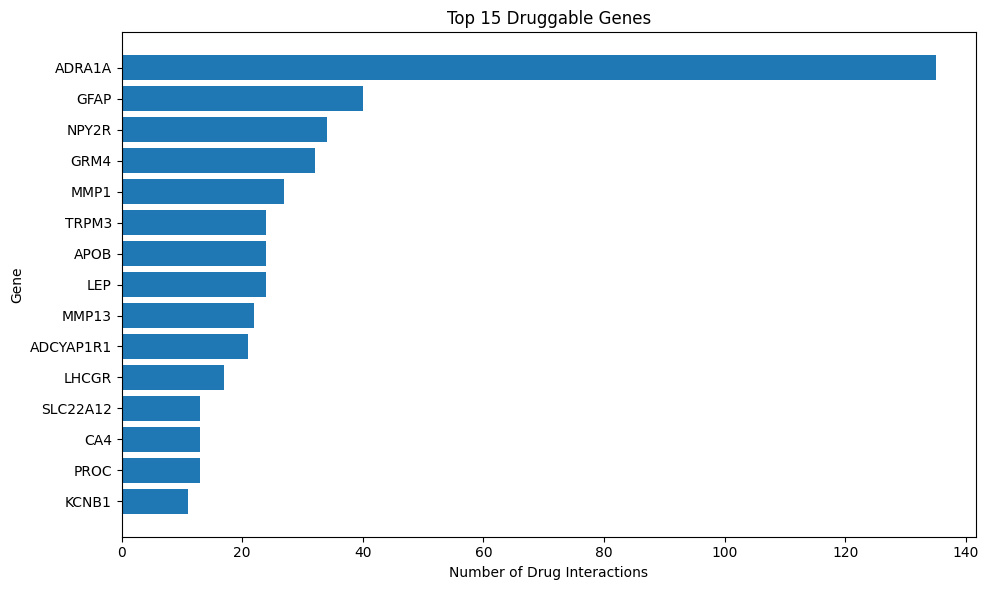

In [0]:
import matplotlib.pyplot as plt

# Top 15 genes
top15_genes = drugs_per_gene.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15_genes["Gene"],
    top15_genes["Number_of_Drugs"]
)

plt.xlabel("Number of Drug Interactions")
plt.ylabel("Gene")
plt.title("Top 15 Druggable Genes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/top15_genes_drug_interactions.png", dpi=300)
plt.show()

## Figure 2. Top drugs targeting multiple differentially expressed genes.

The chart highlights drugs interacting with multiple significantly dysregulated genes.
Drugs targeting several genes may represent stronger candidates for computational drug repurposing studies.

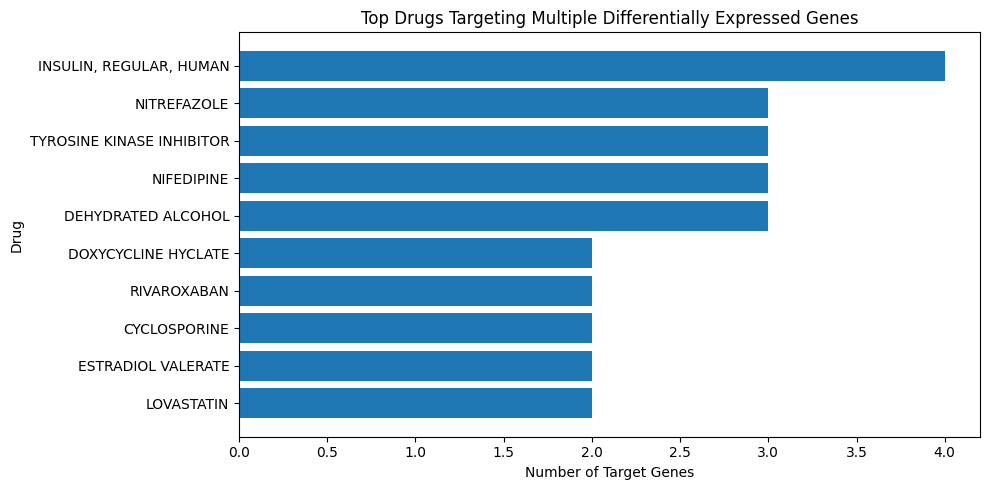

In [0]:
top20_drugs = drug_target_summary.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top20_drugs["Drug"],
    top20_drugs["Number_of_Genes"]
)

plt.xlabel("Number of Target Genes")
plt.ylabel("Drug")

plt.title("Top Drugs Targeting Multiple Differentially Expressed Genes")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("figures/top20_drugs.png", dpi=300)

plt.show()

## Figure 3. Distribution of drug–gene interaction types.

The interaction types retrieved from DGIdb were summarized to understand the predominant mechanisms of action among identified drug–gene interactions.

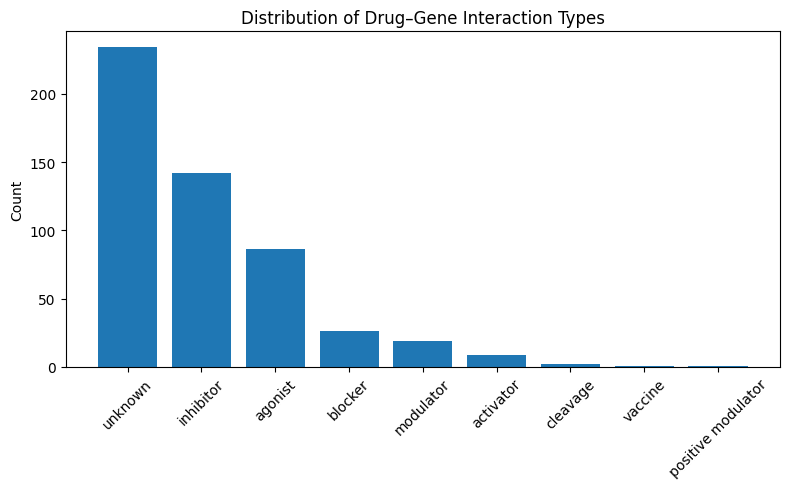

In [0]:
plt.figure(figsize=(8,5))

plt.bar(
    interaction_counts["Interaction_Type"],
    interaction_counts["Count"]
)

plt.xticks(rotation=45)

plt.ylabel("Count")

plt.title("Distribution of Drug–Gene Interaction Types")

plt.tight_layout()

plt.savefig("figures/interaction_types.png", dpi=300)

plt.show()

## Figure 4. Gene–drug interaction network

In [0]:
%pip install networkx

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


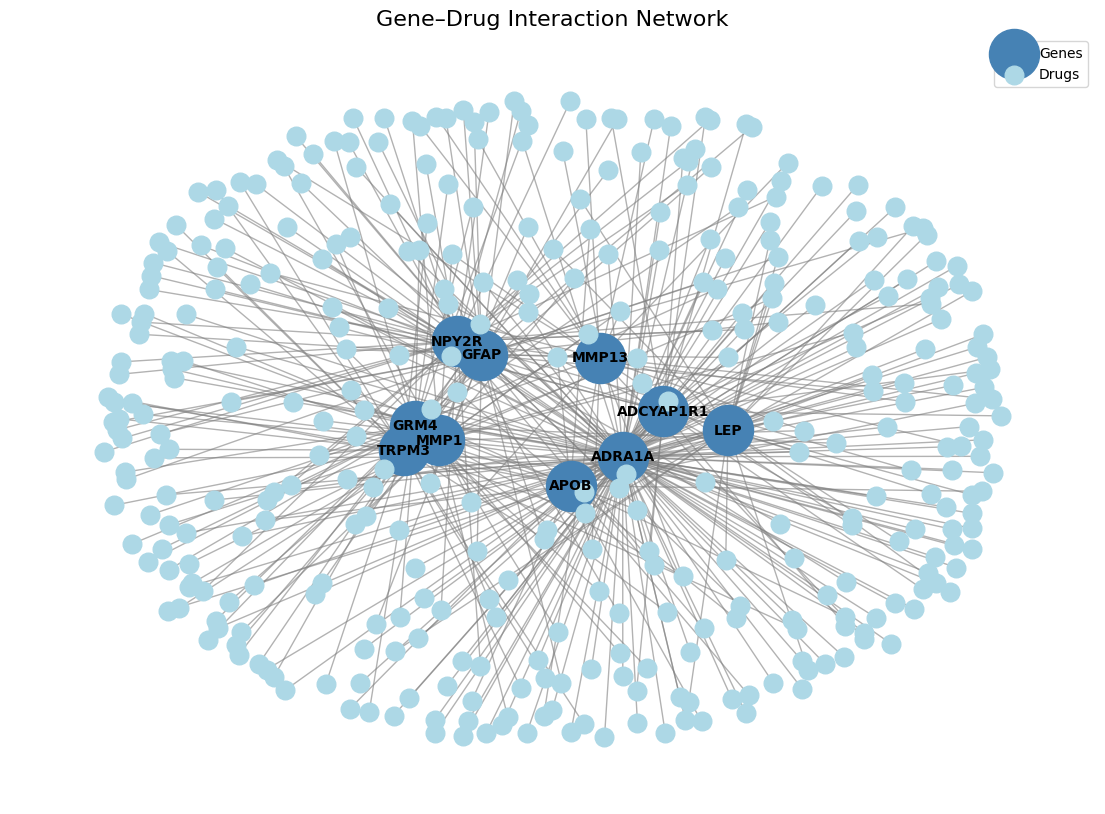

In [0]:
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------
# Figure 4: Gene–Drug Interaction Network
# ---------------------------------------

# Select the 10 genes with the most drug interactions
top_genes = drugs_per_gene.head(10)["Gene"].tolist()

# Keep only interactions involving these genes
network_df = drug_clean_df[drug_clean_df["Gene"].isin(top_genes)]

# Create graph
G = nx.Graph()

# Add edges (Gene <-> Drug)
for _, row in network_df.iterrows():
    G.add_edge(row["Gene"], row["Drug"])

# Separate gene and drug nodes
gene_nodes = network_df["Gene"].unique()
drug_nodes = network_df["Drug"].unique()

# Create layout
plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, k=0.45, seed=42)

# Draw gene nodes
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=gene_nodes,
    node_size=1300,
    node_color="steelblue",
    label="Genes"
)

# Draw drug nodes
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=drug_nodes,
    node_size=180,
    node_color="lightblue",
    label="Drugs"
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    alpha=0.6
)

# Label ONLY genes
gene_labels = {gene: gene for gene in gene_nodes}

nx.draw_networkx_labels(
    G,
    pos,
    labels=gene_labels,
    font_size=10,
    font_weight="bold"
)

plt.title("Gene–Drug Interaction Network", fontsize=16)
plt.legend()
plt.axis("off")

# Save figure
plt.savefig("figures/gene_drug_network.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Conclusion

This analysis integrated differential gene expression results from TCGA-BRCA with DGIdb drug–gene interaction data to identify potential drug repurposing candidates.

Key findings include:

- A substantial proportion of the top differentially expressed genes have known drug interactions.
- ADRA1A, GFAP, NPY2R, and several other genes showed the highest number of known drug associations.
- Several drugs were found to target multiple differentially expressed genes, suggesting potential repurposing opportunities.
- The interaction network highlights hub genes that may represent promising therapeutic targets for further investigation.